In [7]:
# Cell 1: Setup and backend fix
%matplotlib inline
%config InlineBackend.figure_format = 'png'  # Fix backend render issue

import numpy as np
import matplotlib.pyplot as plt

# Set reproducibility
np.random.seed(42)


In [8]:
# Cell 2: Generate synthetic return data
n_assets = 3
n_samples = 1000
returns = np.random.normal(loc=0.001, scale=0.02, size=(n_samples, n_assets))

# Confidence level for CVaR
beta = 0.95


In [9]:
# Cell 3: Define CVaR objective function
def compute_F(x, alpha, returns, beta):
    """
    Compute CVaR objective:
    F_beta(x, alpha) = alpha + 1 / ((1 - beta) * N) * sum([loss - alpha]^+)
    """
    losses = -returns.dot(x)
    tail_losses = np.maximum(losses - alpha, 0)
    return alpha + np.mean(tail_losses) / (1 - beta)


In [10]:
# Cell 4: Compute gradients of F_beta with respect to x and alpha
def compute_gradients(x, alpha, returns, beta):
    losses = -returns.dot(x)
    tail_indicator = losses > alpha
    N = len(losses)

    grad_x = -np.sum(returns[tail_indicator].T, axis=1) / (N * (1 - beta))
    grad_alpha = 1 - np.sum(tail_indicator) / (N * (1 - beta))

    return grad_x, grad_alpha


In [11]:
# Cell 5: Initialize parameters
x = np.ones(n_assets) / n_assets  # Equal weights
alpha = np.percentile(-returns.dot(x), 100 * beta)  # Empirical VaR

learning_rate = 0.1
epochs = 10

loss_history = []


In [12]:
# Cell 6: Gradient descent loop
for epoch in range(epochs):
    grad_x, grad_alpha = compute_gradients(x, alpha, returns, beta)

    # Update parameters
    x -= learning_rate * grad_x
    alpha -= learning_rate * grad_alpha

    # Project weights back onto the simplex
    x = np.maximum(x, 0)
    x /= np.sum(x)

    # Record objective value
    F_val = compute_F(x, alpha, returns, beta)
    loss_history.append(F_val)


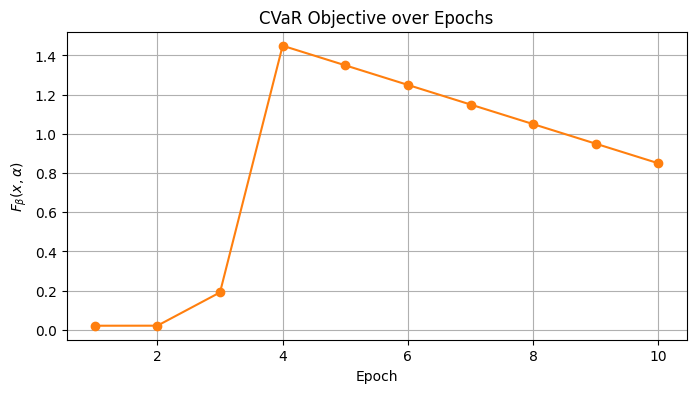

In [14]:
# Cell 7: Visualize CVaR objective value over training
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='tab:orange')
plt.title('CVaR Objective over Epochs')
plt.xlabel('Epoch')
plt.ylabel(r'$F_\beta(x, \alpha)$')
plt.grid(True)
plt.show()
